# Licence Plate Detection — YOLO Only
Detect licence plates in images from the `data-images` folder using **YOLOv11** (`morsetechlab/yolov11-license-plate-detection`).
No OCR — purely bounding-box object detection.

## 1. Import Libraries

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("Libraries imported.")

Libraries imported.


## 2. Settings

In [ ]:
IMAGE_FOLDER     = Path("data-images")
CONF_THRESHOLD   = 0.30          # plate detection confidence
CAR_CONF         = 0.40          # car detection confidence
CAR_MODEL_NAME   = "models/yolo11n.pt"
PLATE_MODEL_NAME = "models/license-plate-finetune-v1n.onnx"
CAR_CLASS_IDS    = {2, 5, 7}     # COCO: car=2, bus=5, truck=7
SUPPORTED_EXT    = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print(f"Folder      : {IMAGE_FOLDER.resolve()}")
print(f"Car model   : {CAR_MODEL_NAME}")
print(f"Plate model : {PLATE_MODEL_NAME}")
print(f"Car conf    : {CAR_CONF}  |  Plate conf: {CONF_THRESHOLD}")


Folder      : C:\Users\krist\Documents\GitHub\Object-Detection-Research\data-images
Car model   : models/yolov8n.pt
Plate model : models/license-plate-finetune-v1n.onnx
Car conf    : 0.4  |  Plate conf: 0.3


## 3. Load Models
Load both the general-purpose car detector (`yolov8n.pt`) and the fine-tuned licence-plate detector.

In [3]:
car_model   = YOLO(CAR_MODEL_NAME)
plate_model = YOLO(PLATE_MODEL_NAME)
print("Car model loaded  :", CAR_MODEL_NAME)
print("Plate model loaded:", PLATE_MODEL_NAME)


WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Car model loaded  : models/yolov8n.pt
Plate model loaded: models/license-plate-finetune-v1n.onnx


## 4. Discover Images

In [4]:
if not IMAGE_FOLDER.is_dir():
    raise FileNotFoundError(f"Folder not found: {IMAGE_FOLDER.resolve()}")

image_files = sorted(
    p for p in IMAGE_FOLDER.iterdir()
    if p.suffix.lower() in SUPPORTED_EXT
)

print(f"Found {len(image_files)} image(s):")
for p in image_files:
    print(f"  • {p.name}")

Found 3 image(s):
  • dsc0226.jpg
  • DSC_1939.JPG
  • nederland150.jpg


## 5. Stage 1 — Vehicle Detection
Run `yolov8n` on every image to locate vehicles (car / bus / truck). Results are stored with the cropped vehicle regions ready for Stage 2.

In [5]:
car_results = []

for img_path in image_files:
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print(f"  [skip] Could not read {img_path.name}")
        continue

    car_out = car_model(img_bgr, conf=CAR_CONF, verbose=False)[0]
    cars = []
    for cb in car_out.boxes:
        if int(cb.cls[0]) not in CAR_CLASS_IDS:
            continue
        cx1, cy1, cx2, cy2 = map(int, cb.xyxy[0].tolist())
        crop = img_bgr[cy1:cy2, cx1:cx2]
        if crop.size == 0:
            continue
        cars.append({
            "x1": cx1, "y1": cy1, "x2": cx2, "y2": cy2,
            "conf": round(float(cb.conf[0]), 4),
            "crop": crop,
        })

    if not cars:
        print(f"  [skip] No vehicles found in {img_path.name}")
        continue

    car_results.append({"file": img_path.name, "img_bgr": img_bgr, "cars": cars})
    print(f"  ✓ {img_path.name}  →  {len(cars)} vehicle(s)")

print(f"\nDone. {len(car_results)} image(s) with vehicles.")


  ✓ dsc0226.jpg  →  1 vehicle(s)
  ✓ DSC_1939.JPG  →  3 vehicle(s)
  [skip] No vehicles found in nederland150.jpg

Done. 2 image(s) with vehicles.


## 6. Visualise Vehicle Detections
Full images with bounding boxes around every detected vehicle.

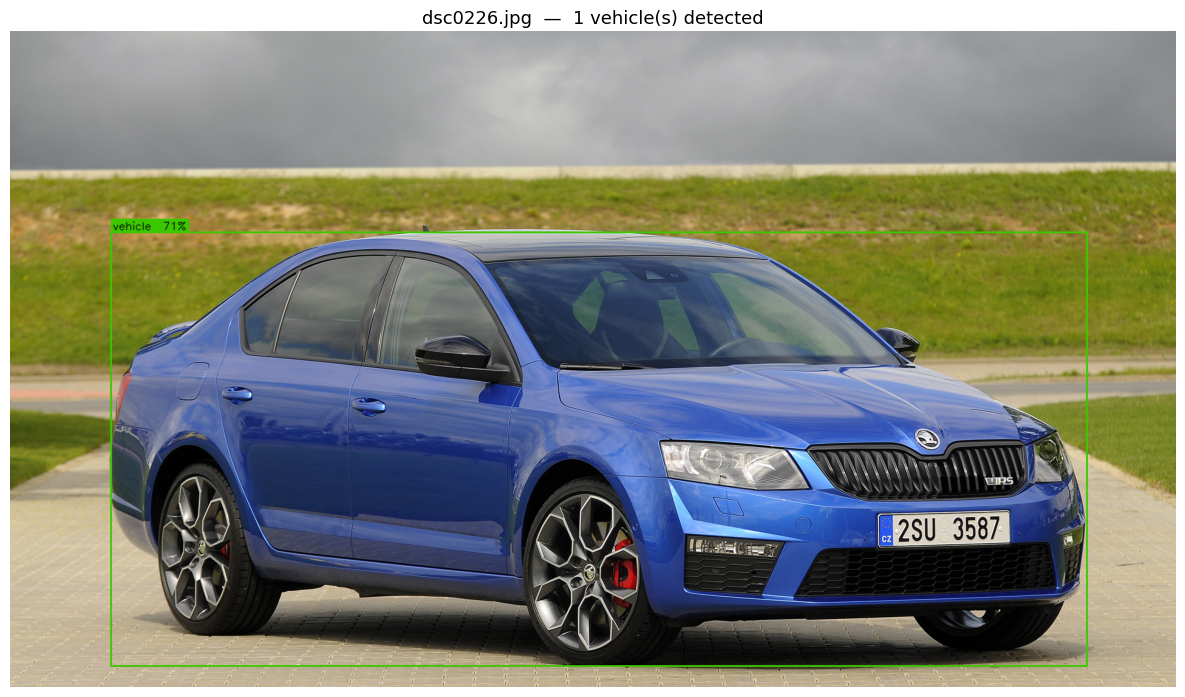

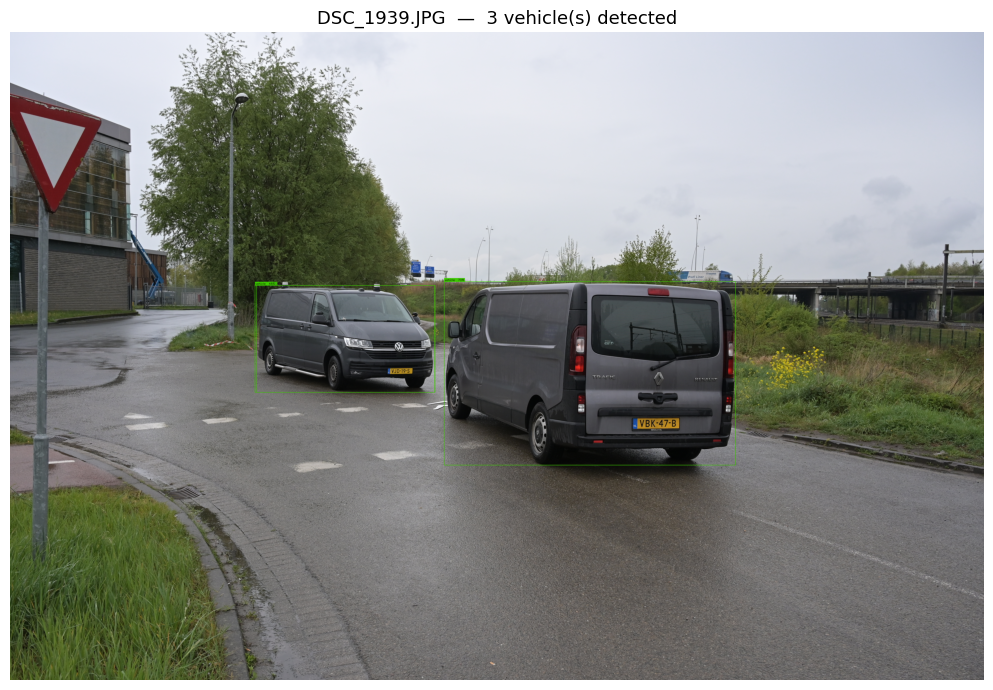

In [6]:
CAR_COLOR   = (  0, 200,  60)   # BGR green
LABEL_COLOR = (  0,   0,   0)   # black text

for result in car_results:
    img  = result["img_bgr"].copy()
    cars = result["cars"]

    for c in cars:
        label = f"vehicle  {c['conf']:.0%}"
        cv2.rectangle(img, (c["x1"], c["y1"]), (c["x2"], c["y2"]), CAR_COLOR, 2)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(img, (c["x1"], c["y1"] - th - 8), (c["x1"] + tw + 6, c["y1"]), CAR_COLOR, -1)
        cv2.putText(img, label, (c["x1"] + 3, c["y1"] - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, LABEL_COLOR, 1, cv2.LINE_AA)

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{result['file']}  —  {len(cars)} vehicle(s) detected", fontsize=13)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


## 7. Vehicle Crops
Each vehicle region cropped out of the original image — these are the inputs to Stage 2.

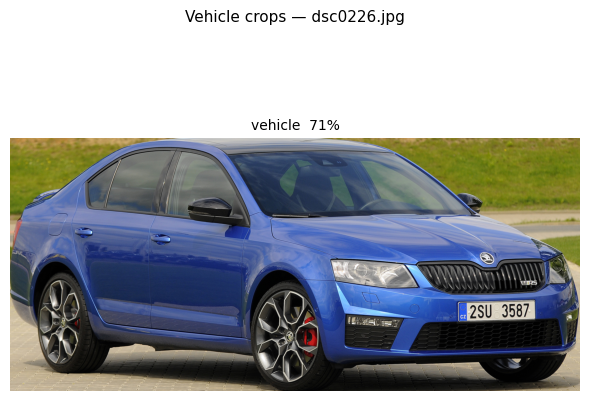

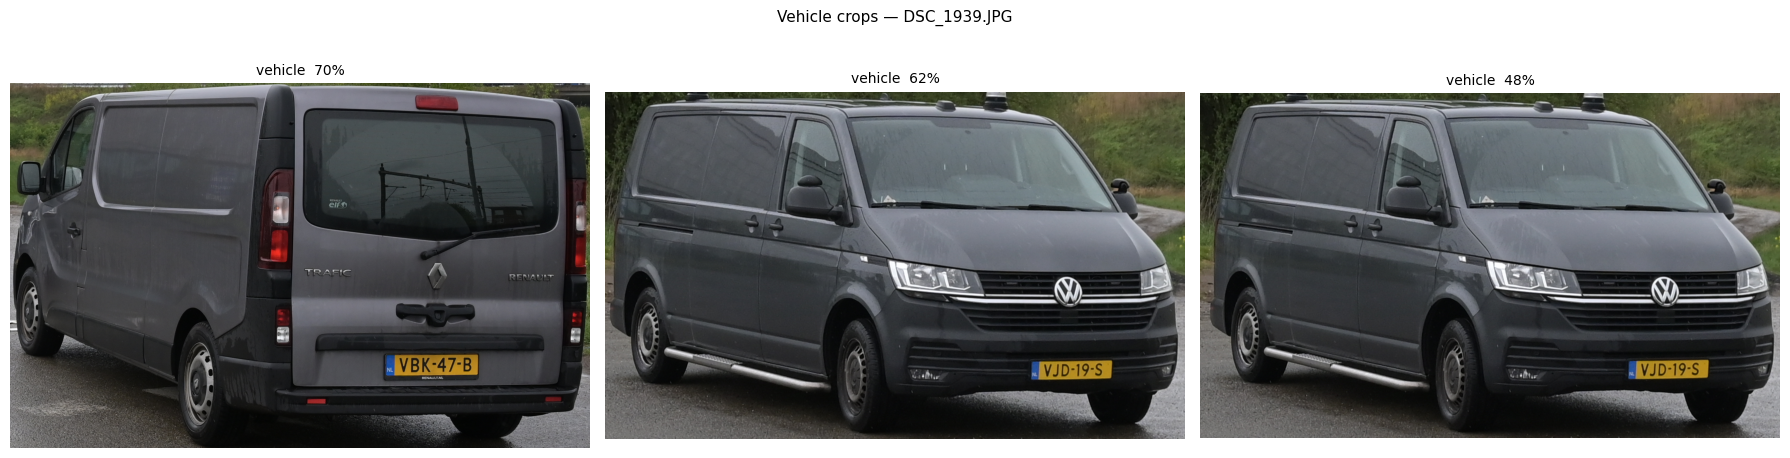

In [7]:
for result in car_results:
    cars = result["cars"]
    n    = len(cars)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, c in zip(axes, cars):
        ax.imshow(cv2.cvtColor(c["crop"], cv2.COLOR_BGR2RGB))
        ax.set_title(f"vehicle  {c['conf']:.0%}", fontsize=10)
        ax.axis("off")

    plt.suptitle(f"Vehicle crops — {result['file']}", fontsize=11)
    plt.tight_layout()
    plt.show()


## 8. Stage 2 — Licence Plate Detection
Each vehicle crop from Stage 1 is passed to the fine-tuned plate model. Detected plate boxes are stored in crop-local coordinates.

In [8]:
for result in car_results:
    total = 0
    for car in result["cars"]:
        plate_out = plate_model(car["crop"], conf=CONF_THRESHOLD, verbose=False)[0]
        plate_boxes = []
        for pb in plate_out.boxes:
            px1, py1, px2, py2 = map(int, pb.xyxy[0].tolist())
            plate_boxes.append({
                "x1": px1, "y1": py1, "x2": px2, "y2": py2,
                "conf": round(float(pb.conf[0]), 4),
            })
        car["plate_boxes"] = plate_boxes
        total += len(plate_boxes)
    print(f"  ✓ {result['file']}  →  {total} plate(s)")

print("\nPlate detection done.")


Loading models/license-plate-finetune-v1n.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider
  ✓ dsc0226.jpg  →  1 plate(s)
  ✓ DSC_1939.JPG  →  3 plate(s)

Plate detection done.


## 9. Visualise Plate Detections
Each vehicle crop with green bounding boxes drawn around detected licence plates.

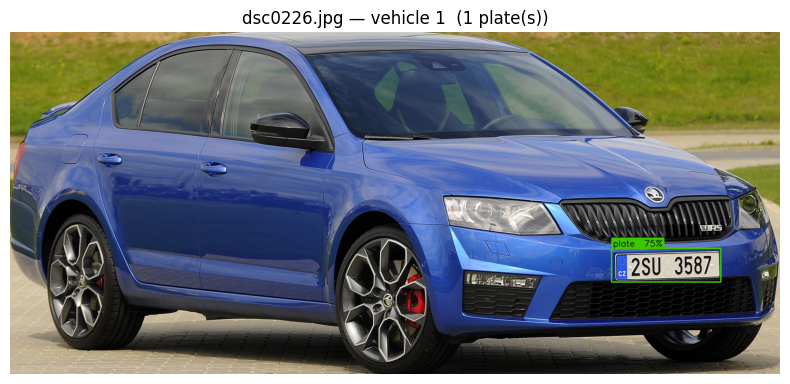

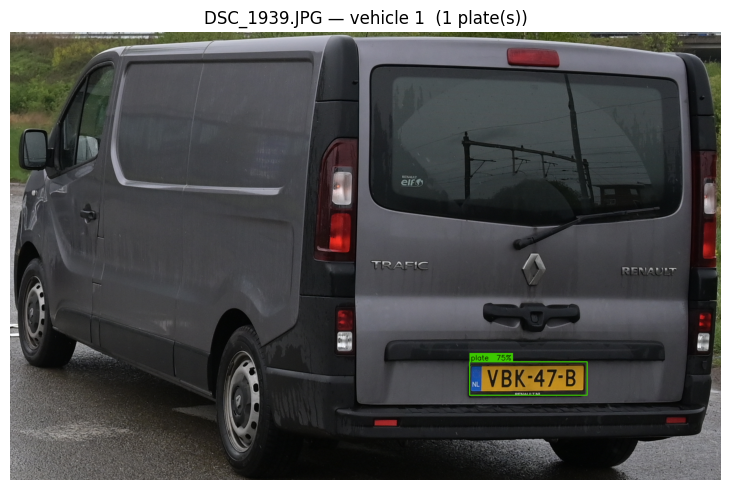

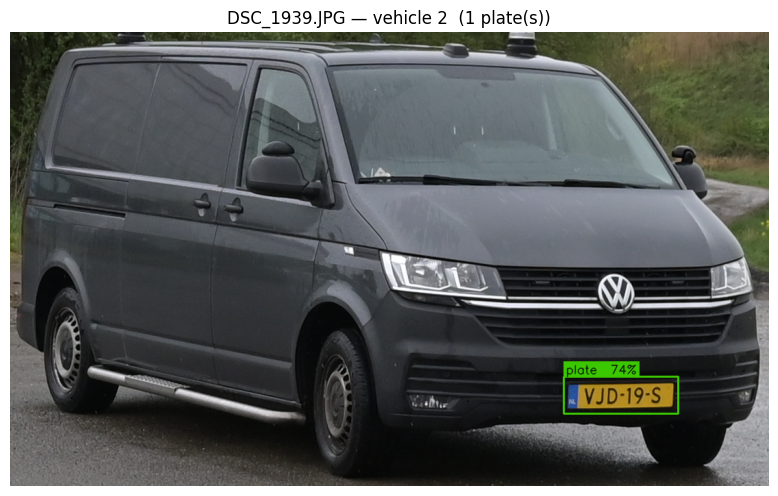

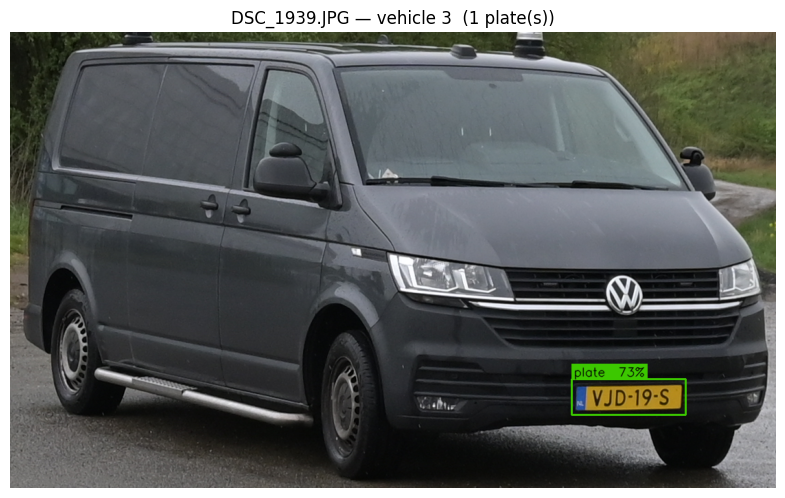

In [9]:
BOX_COLOR   = (  0, 200,  60)   # BGR green — plates
PLATE_LABEL = (  0,   0,   0)   # black text

for result in car_results:
    for i, car in enumerate(result["cars"]):
        plates = car.get("plate_boxes", [])
        crop   = car["crop"].copy()

        for b in plates:
            label = f"plate  {b['conf']:.0%}"
            cv2.rectangle(crop, (b["x1"], b["y1"]), (b["x2"], b["y2"]), BOX_COLOR, 2)
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
            cv2.rectangle(crop, (b["x1"], b["y1"] - th - 8), (b["x1"] + tw + 6, b["y1"]), BOX_COLOR, -1)
            cv2.putText(crop, label, (b["x1"] + 3, b["y1"] - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, PLATE_LABEL, 1, cv2.LINE_AA)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.set_title(
            f"{result['file']} — vehicle {i + 1}  ({len(plates)} plate(s))", fontsize=12
        )
        ax.axis("off")
        plt.tight_layout()
        plt.show()


## 10. Plate Crops
Close-up of every detected licence plate region.

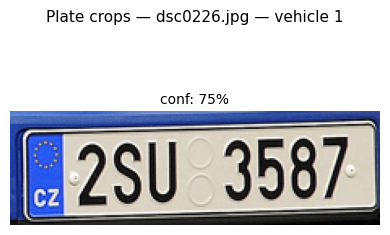

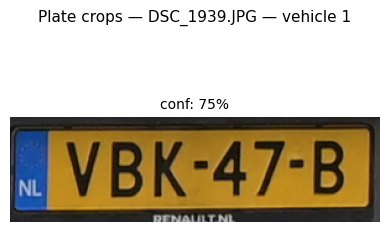

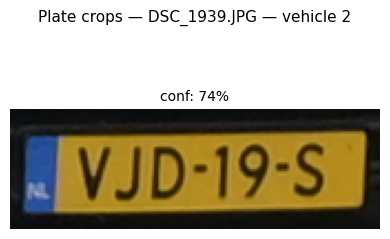

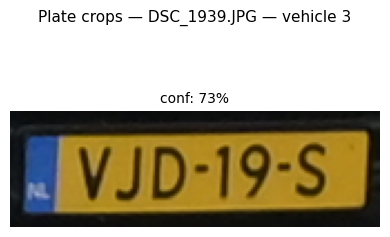

In [10]:
for result in car_results:
    for i, car in enumerate(result["cars"]):
        plates = car.get("plate_boxes", [])
        if not plates:
            print(f"No plates — {result['file']} vehicle {i + 1}")
            continue

        crop = car["crop"]
        n    = len(plates)
        fig, axes = plt.subplots(1, n, figsize=(4 * n, 3))
        if n == 1:
            axes = [axes]

        for ax, b in zip(axes, plates):
            plate_crop = crop[b["y1"]:b["y2"], b["x1"]:b["x2"]]
            ax.imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
            ax.set_title(f"conf: {b['conf']:.0%}", fontsize=10)
            ax.axis("off")

        plt.suptitle(f"Plate crops — {result['file']} — vehicle {i + 1}", fontsize=11)
        plt.tight_layout()
        plt.show()
